## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image

FIGURES = Path("../figures")
PLOTS = Path("../plots")
FIGURES.mkdir(exist_ok=True)
PLOTS.mkdir(exist_ok=True)

## Exact solution

In [2]:
def exact_solution(d, w0, t):
    """Exact x(t) of the damped oscillator in all three regimes, with x(0) = 1 and x'(0) = 0.

    d is the decay rate gamma / 2m, w0 the natural frequency sqrt(k / m), t a torch.Tensor.
    """
    if d < w0:
        # Underdamped
        w = np.sqrt(w0**2 - d**2)
        phi = np.arctan(-d / w)
        A = 1 / (2 * np.cos(phi))
        return 2 * A * torch.exp(-d * t) * torch.cos(w * t + phi)

    elif d == w0:
        # Critically damped: x(t) = (1 + d t) e^(-d t)
        return (1 + d * t) * torch.exp(-d * t)

    else:
        # Overdamped: x(t) = A e^(r1 t) + B e^(r2 t), r1,2 = -d +/- sqrt(d^2 - w0^2)
        beta = np.sqrt(d**2 - w0**2)
        r1 = -d + beta
        r2 = -d - beta
        # From x(0) = 1 and x'(0) = 0
        A = -r2 / (r1 - r2)
        B = r1 / (r1 - r2)
        return A * torch.exp(r1 * t) + B * torch.exp(r2 * t)

## Solving with a NN

### Neural Network Architecture Design

Design a neural network to approximate the SHO solution. Here are our key design choices:

Architecture: Fully Connected (Feed-Forward) Network
- Input layer: 1 neuron (time t)
- Hidden layers: Multiple layers with many neurons
- Output layer: 1 neuron (position x)

Why this structure?
- We're learning a function x(t): one input -> one output
- Hidden layers allow the network to learn complex, non-linear mappings
- More layers and neurons = more capacity to represent oscillatory behavior

Activation Function: Tanh
We use tanh for several important reasons:
- Smoothness: tanh is infinitely differentiable, which is crucial because we'll compute (dx/dt) and (d^2x/dt^2) through the network
- Bounded output: tanh outputs values in [-1, 1], similar to our oscillator's bounded motion
- Zero-centered: Unlike ReLU, tanh can naturally represent both positive and negative values

Note: ReLU would be problematic here because its second derivative is zero everywhere (except at the kink), making it impossible to satisfy our physics equation!

In [3]:
class FCN(torch.nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh

        self.input_layer = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )

        hidden = []
        for _ in range(N_LAYERS - 1):
            hidden.append(nn.Linear(N_HIDDEN, N_HIDDEN))
            hidden.append(activation())
        self.hidden_layers = nn.Sequential(*hidden)

        self.output_layer = nn.Linear(N_HIDDEN, N_OUTPUT)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layers(x)
        x = self.output_layer(x)
        return x

### What is a Damped Oscillator?

Unlike the simple harmonic oscillator where energy is conserved, the **damped harmonic oscillator** is a dissipative system — energy is lost over time (e.g., due to friction or air resistance). Because of this, the standard Lagrangian formulation doesn't directly apply.

However, we can define a **pseudo-Lagrangian** that produces the correct equation of motion:

\begin{equation}
L = \frac{1}{2} m\left(\frac{dx}{dt}\right)^2 + \gamma x \frac{dx}{dt} - \frac{1}{2} kx^2
\end{equation}

### The Equation of Motion

Applying the Euler-Lagrange equation gives us:

\begin{equation}
m \frac{d^2x}{dt^2} + \gamma \frac{dx}{dt} + kx = 0
\end{equation}

where:
- $m$ is the **mass**
- $\gamma$ is the **damping coefficient** (controls energy dissipation)
- $k$ is the **spring constant**
- $x$ is the **displacement**

### Three Damping Regimes

Defining $d = \frac{\gamma}{2m}$ (decay rate) and $\omega_0 = \sqrt{\frac{k}{m}}$ (natural frequency), the behavior depends on their relationship:

\begin{array}{|c|p{5cm}|c|p{5cm}|}
\hline
\textbf{Regime} & \textbf{Condition} & \textbf{Code Vars} & \textbf{Behavior} \\
\hline
\text{Underdamped} &
\gamma^{2} < 4mk &
d < \omega_{0} &
\text{Oscillates with decreasing amplitude} \\
\hline
\text{Critically damped} &
\gamma^{2} = 4mk &
d = \omega_{0} &
\text{Fastest return to equilibrium (no oscillation)} \\
\hline
\text{Overdamped} &
\gamma^{2} > 4mk &
d > \omega_{0} &
\text{Slower than critical; exponential decay, no oscillation} \\
\hline
\end{array}

### Exact Solutions

**1. Underdamped** ($d < \omega_0$):

\begin{equation}
x(t) = e^{-dt} [A \cos(\omega_d t) + B \sin(\omega_d t)]
\end{equation}

where $\omega_d = \sqrt{\omega_0^2 - d^2}$ is the damped angular frequency.

**2. Critically damped** ($d = \omega_0$):

\begin{equation}
x(t) = (A + Bt) e^{-dt}
\end{equation}

**3. Overdamped** ($d > \omega_0$):

\begin{equation}
x(t) = e^{-dt} \left[A e^{t\sqrt{d^2 - \omega_0^2}} + B e^{-t\sqrt{d^2 - \omega_0^2}}\right]
\end{equation}

*Note: These solutions assume no external forces. Constants $A$ and $B$ are determined by initial conditions.*

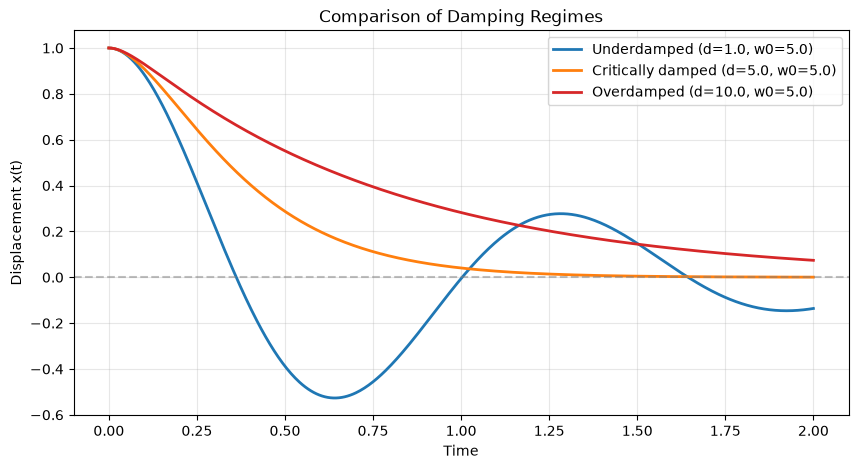

Underdamped: oscillates with decreasing amplitude (d=1.0 < ω₀=5.0)
Critically damped: fastest return to equilibrium (d=5.0 = ω₀=5.0)
Overdamped: slower return, no oscillation (d=10.0 > ω₀=5.0)


In [4]:
t_plot = torch.linspace(0, 2, 500).view(-1, 1)
w0_demo = 5.0

d_under = 1.0
x_underdamped = exact_solution(d_under, w0_demo, t_plot)

d_critical = w0_demo
x_critical = exact_solution(d_critical, w0_demo, t_plot)

d_over = 10.0
x_overdamped = exact_solution(d_over, w0_demo, t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot[:, 0], x_underdamped[:, 0], label=f"Underdamped (d={d_under}, w0={w0_demo})", lw=2, color="tab:blue")
plt.plot(t_plot[:, 0], x_critical[:, 0], label=f"Critically damped (d={d_critical}, w0={w0_demo})", lw=2, color="tab:orange")
plt.plot(t_plot[:, 0], x_overdamped[:, 0], label=f"Overdamped (d={d_over}, w0={w0_demo})", lw=2, color="tab:red")
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Displacement x(t)")
plt.title("Comparison of Damping Regimes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Underdamped: oscillates with decreasing amplitude (d={d_under} < ω₀={w0_demo})")
print(f"Critically damped: fastest return to equilibrium (d={d_critical} = ω₀={w0_demo})")
print(f"Overdamped: slower return, no oscillation (d={d_over} > ω₀={w0_demo})")

## Part 1: Forward Problem — Training the PINN

### What is a Physics-Informed Neural Network?

A **PINN** embeds physical laws directly into the neural network's loss function. Instead of just fitting data, the network must also satisfy the governing differential equation.

For the damped oscillator, our total loss combines:
1. **Boundary loss**: Ensures correct initial conditions ($x(0) = 1$, $\dot{x}(0) = 0$)
2. **Physics loss**: Ensures the differential equation $\ddot{x} + \gamma\dot{x} + kx = 0$ is satisfied
3. **Data loss**: MSE against the exact solution at the collocation points (in `train_pinn` below, this term carries most of the weight)


### Computing Derivatives Through the Network

To evaluate the physics loss, we need $\frac{dx}{dt}$ and $\frac{d^2x}{dt^2}$. PyTorch's **automatic differentiation** computes these exactly:

```python
torch.autograd.grad(output, input, grad_outputs=..., create_graph=True)
```

Key parameters:
- `create_graph=True`: Allows computing higher-order derivatives
- `grad_outputs`: Specifies which outputs to differentiate (typically `torch.ones_like(output)`)

## Physics Informed Neural Network


In [5]:
def calc_output_and_gradients(model: torch.nn.Module, t: torch.Tensor):
    """Return u(t), du/dt and d2u/dt2, all computed through the network with autograd."""
    u_t = model(t)
    dudt = torch.autograd.grad(
        outputs=u_t,
        inputs=t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True,
    )[0]
    d2udt2 = torch.autograd.grad(
        outputs=dudt,
        inputs=t,
        grad_outputs=torch.ones_like(dudt),
        create_graph=True,
    )[0]
    return u_t, dudt, d2udt2

In [6]:
torch.manual_seed(123)
pinn = FCN(1, 1, 32, 3)

t_test = torch.tensor([[0.5], [0.6], [0.7]]).requires_grad_(True)
u_t, dudt, d2dudt2 = calc_output_and_gradients(pinn, t_test)

for tensor in (u_t, dudt, d2dudt2):
    assert isinstance(tensor, torch.Tensor) and tensor.shape == t_test.shape

assert torch.allclose(u_t, pinn(t_test))
assert torch.allclose(dudt, torch.autograd.grad(
    outputs=u_t, inputs=t_test, grad_outputs=torch.ones_like(u_t), create_graph=True
)[0])
assert torch.allclose(d2dudt2, torch.autograd.grad(
    outputs=dudt, inputs=t_test, grad_outputs=torch.ones_like(dudt), create_graph=True
)[0])

print("All assert statements passed!")

All assert statements passed!


In [7]:
def physics_loss(amplitude, first_derivative, second_derivative, w0, gamma):
    """Mean squared residual of x'' + gamma x' + w0^2 x = 0."""
    return torch.mean((second_derivative + gamma * first_derivative + (w0 ** 2) * amplitude) ** 2)

In [8]:
zero = torch.tensor([0.0])
assert physics_loss(zero, zero, zero, zero, zero) == torch.tensor([0.0])

one = torch.tensor([1.0])
assert physics_loss(one, one, one, one, one) == torch.tensor([9.0])

print("All assert statements passed!")

All assert statements passed!


In [9]:
def compute_initial_condition_loss(predicted_amplitude, predicted_first_derivative, expected_amplitude=1, expected_first_derivative=0):
    """Squared error of x(0) and x'(0) against their target values."""
    return (predicted_amplitude - expected_amplitude) ** 2 + (predicted_first_derivative - expected_first_derivative) ** 2

In [10]:
# Test when predicted values match the expected values
assert compute_initial_condition_loss(1, 0) == 0, "Test failed: Expected loss is 0 when predicted values match the expected values"

# Test when predicted values do not match the expected values
assert compute_initial_condition_loss(2, 1) == 2, "Test failed: Expected loss is 2 when predicted values do not match the expected values"

# Test when expected values are different from the default values
assert compute_initial_condition_loss(2, 1, 2, 1) == 0, "Test failed: Expected loss is 0 when predicted values match the non-default expected values"

# Test with negative values
assert compute_initial_condition_loss(-1, -1) == 5, "Test failed: Expected loss is 5 when predicted values are negative"

# Test with floating point values
assert compute_initial_condition_loss(1.5, 0.5) == 0.5, "Test failed: Expected loss is 0.5 when predicted values are floating point numbers"

In [11]:
def ema(x, alpha=0.00002):
    """Exponential moving average, used to smooth the loss curves."""
    x = np.asarray(x, dtype=np.float64)
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

In [12]:
def determine_regime(d, w0):
    if d < w0:
        regime = "Underdamped"
    elif d == w0:
        regime = "Critically Damped"
    else:
        regime = "Overdamped"
        
    return regime

In [13]:
def plot_pinn_solution(t_physics, t_boundary, pinn, d, w0, training_step, t_max=1.0):
    t_test = torch.linspace(0, t_max, 300).view(-1, 1)
    u_exact = exact_solution(d, w0, t_test)
    u = pinn(t_test).detach()
    regime = determine_regime(d, w0)

    plt.figure(figsize=(8, 3))
    plt.scatter(
        t_physics.detach()[:, 0], torch.zeros_like(t_physics)[:, 0], label="Physics sampling points", s=20, lw=0, color="tab:green", alpha=0.6
    )
    plt.scatter(t_boundary.detach()[:, 0], torch.zeros_like(t_boundary)[:, 0], label="Boundary (t=0)", s=20, lw=0, color="tab:red", alpha=0.6)
    plt.plot(t_test[:, 0], u_exact[:, 0], label="Exact solution", color="tab:grey", lw=2)
    plt.plot(t_test[:, 0], u[:, 0], label="PINN solution", color="tab:green", lw=2)
    plt.axhline(0, color="gray", linestyle="--", alpha=0.3)
    plt.title(f"{regime} (d={d}, ω₀={w0}) — Training step {training_step}")
    plt.xlabel("Time")
    plt.ylabel("x(t)")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.axis("off")

In [14]:
def save_gif_PIL(outfile, files, fps=5, loop=0):
    images = [Image.open(fn) for fn in files]
    images[0].save(outfile, save_all=True, append_images=images[1:], optimize=False, duration=1000 / fps, loop=loop)

In [ ]:
def train_pinn(t_boundary, t_physics, pinn, d, w0, lambda1=1e-1, lambda2=1e-4, lr=1e-3, num_steps=15001, plot_interval=1000, t_max=1.0):
    sho_samples = exact_solution(d, w0, t_physics)

    torch.manual_seed(1)
    files = []
    sho_loss_weight = 1e-4
    initial_condition_loss_weight = 1e-4
    gamma = 2 * d

    optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

    losses_physics = []
    losses_sho = []
    losses_initial_condition = []

    regime = determine_regime(d, w0)

    for i in range(num_steps):
        optimizer.zero_grad()
        sho_predicted = pinn(t_physics)
        loss1 = torch.mean((sho_predicted - sho_samples) ** 2)

        sho_predicted_physics, dtsho_predicted_physics, d2tsho_predicted_physics = calc_output_and_gradients(pinn, t_physics)
        sho_loss = physics_loss(sho_predicted_physics, dtsho_predicted_physics, d2tsho_predicted_physics, w0, gamma)

        initial_sho_x, initial_sho_dt, initial_sho_d2t = calc_output_and_gradients(pinn, t_boundary)
        initial_condition_loss = compute_initial_condition_loss(initial_sho_x, initial_sho_dt)

        loss = loss1 + sho_loss_weight * sho_loss + initial_condition_loss_weight * initial_condition_loss
        loss.backward(retain_graph=True)
        optimizer.step()

        losses_sho.append(sho_loss.item())
        losses_initial_condition.append(initial_condition_loss.item())
        losses_physics.append(loss.item())

        if i % 200 == 0:
            plot_pinn_solution(t_physics, t_boundary, pinn, d, w0, training_step=i, t_max=1.0)
            file = PLOTS / f"{regime.replace(' ', '_')}_physics_{i + 1:08d}.png"
            plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
            files.append(file)
            if i % plot_interval == 0:
                plt.show()
            else:
                plt.close("all")

    lp = np.array(losses_physics)
    ls = np.array(losses_sho)
    li = np.array(losses_initial_condition)

    plt.plot(ema(lp, alpha=0.02), label="Total loss (EMA)")
    plt.plot(ema(ls, alpha=0.02), label="Physics loss (EMA)")
    plt.plot(ema(li, alpha=0.02), label="IC loss (EMA)")
    plt.plot(lp, alpha=0.15, linewidth=1)
    plt.plot(ls, alpha=0.15, linewidth=1)
    plt.plot(li, alpha=0.15, linewidth=1)
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.legend()
    plt.show()

    gif_path = FIGURES / f"{regime.replace(' ', '_')}_physics_nn.gif"
    save_gif_PIL(gif_path, files, fps=20, loop=0)

CASE 1: UNDERDAMPED OSCILLATOR
Parameters: d = 2, ω₀ = 20
Since d < ω₀, the system oscillates with decreasing amplitude


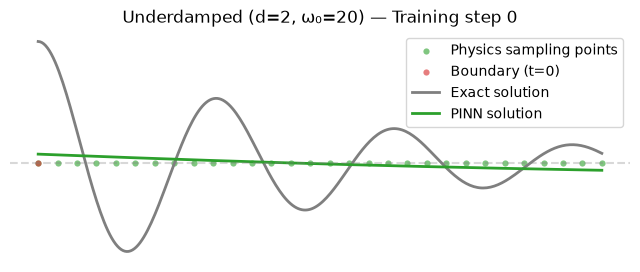

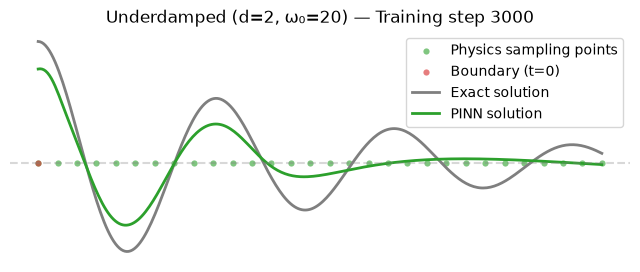

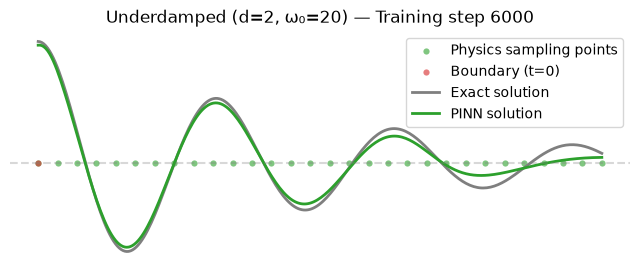

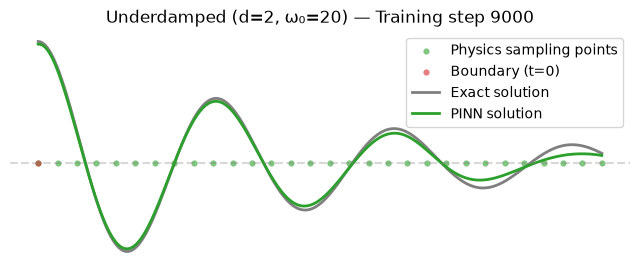

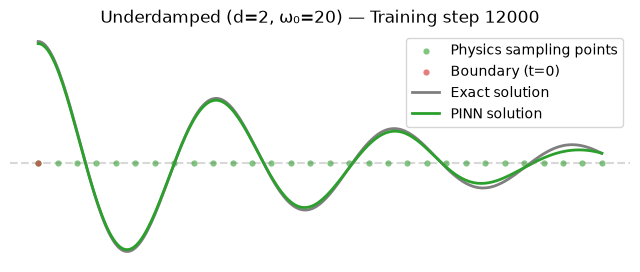

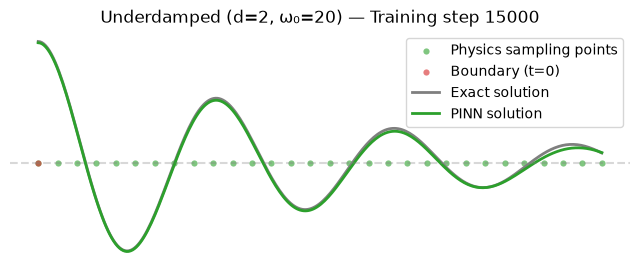

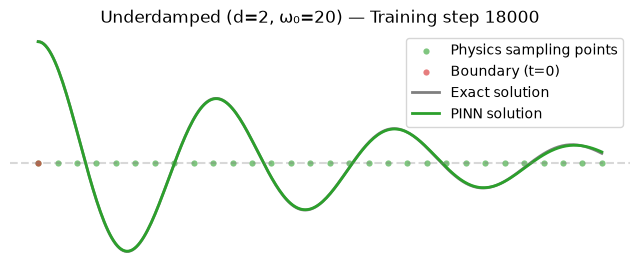

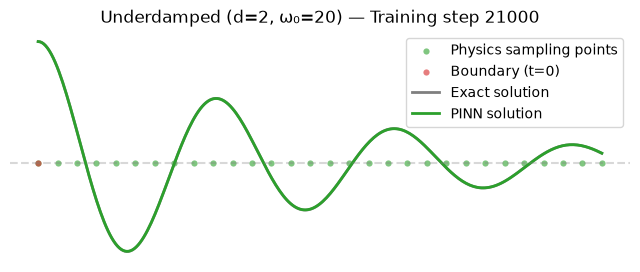

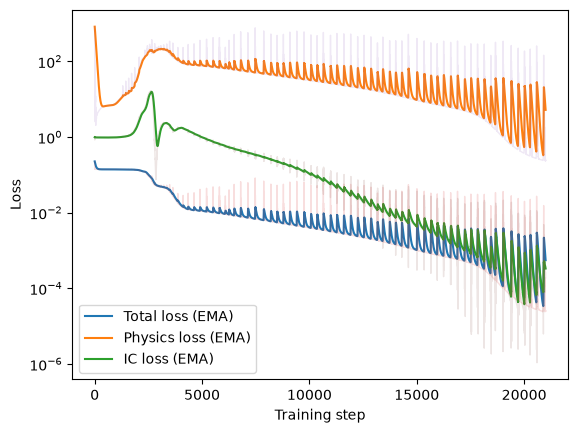

In [19]:
# Case 1: Underdamped (d < w0)
torch.manual_seed(123)

d_under, w0_under = 2, 20
pinn_under = FCN(1, 1, 32, 3)
t_boundary = torch.tensor(0.0).view(-1, 1).requires_grad_(True)
t_physics = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True)

print("=" * 60)
print("CASE 1: UNDERDAMPED OSCILLATOR")
print(f"Parameters: d = {d_under}, ω₀ = {w0_under}")
print("Since d < ω₀, the system oscillates with decreasing amplitude")
print("=" * 60)

train_pinn(t_boundary, t_physics, pinn_under, d_under, w0_under, lambda1=1e-1, lambda2=1e-3, num_steps=21001, plot_interval=3000)

CASE 2: CRITICALLY DAMPED OSCILLATOR
Parameters: d = 5.0, ω₀ = 5.0
Since d = ω₀, the system returns to equilibrium fastest (no oscillation)


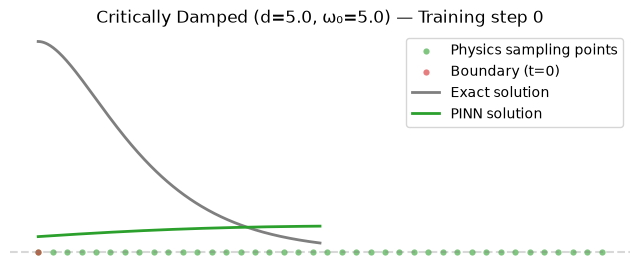

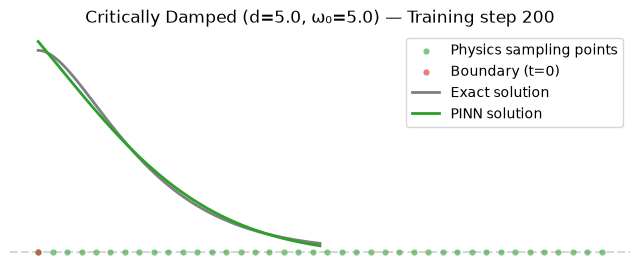

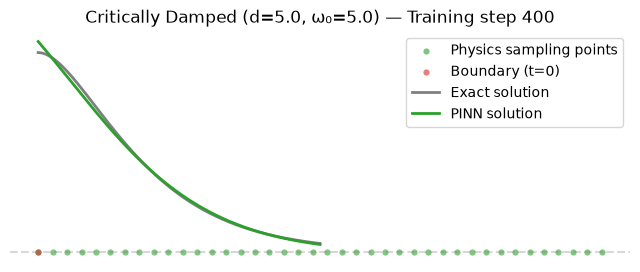

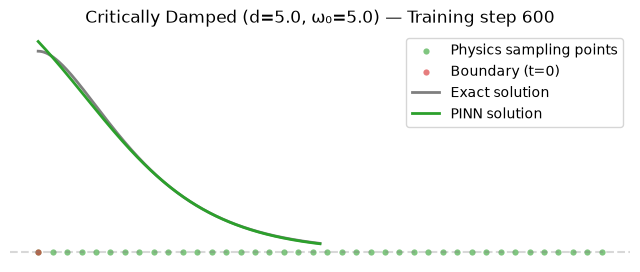

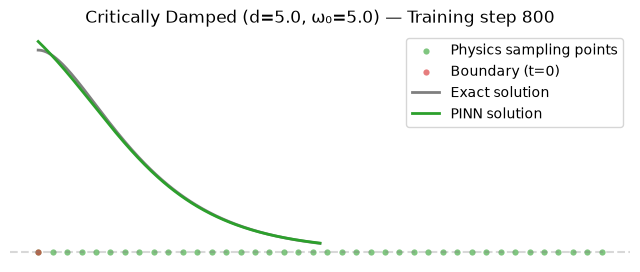

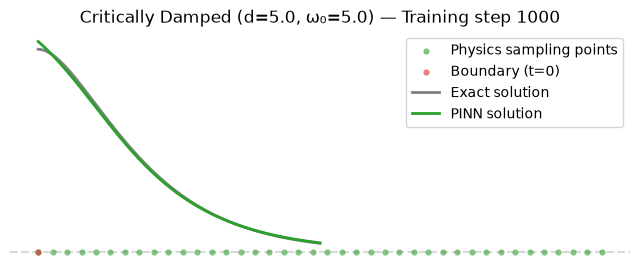

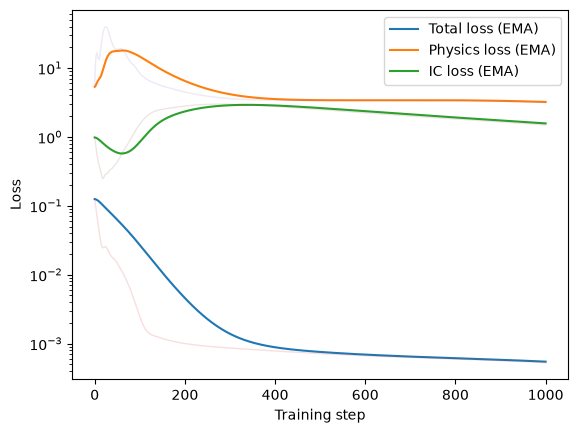

In [ ]:
# Case 2: Critically damped (d = w0)
torch.manual_seed(456)

d_crit, w0_crit = 5.0, 5.0
pinn_crit = FCN(1, 1, 32, 3)
t_boundary = torch.tensor(0.0).view(-1, 1).requires_grad_(True)
t_physics = torch.linspace(0, 2, 40).view(-1, 1).requires_grad_(True)  # longer window for the slower decay

print("=" * 60)
print("CASE 2: CRITICALLY DAMPED OSCILLATOR")
print(f"Parameters: d = {d_crit}, ω₀ = {w0_crit}")
print("Since d = ω₀, the system returns to equilibrium fastest (no oscillation)")
print("=" * 60)

train_pinn(t_boundary, t_physics, pinn_crit, d_crit, w0_crit, lambda1=1e-1, lambda2=1e-4, num_steps=1001, plot_interval=100, t_max=2.0)

CASE 3: OVERDAMPED OSCILLATOR
Parameters: d = 10.0, ω₀ = 5.0
Since d > ω₀, the system decays slowly without oscillation


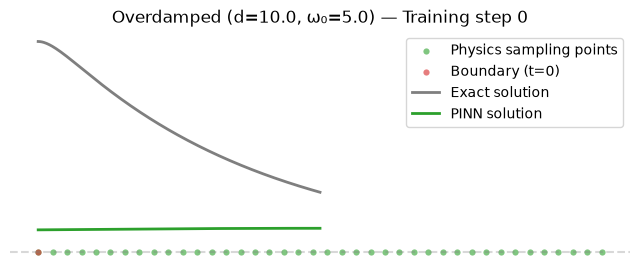

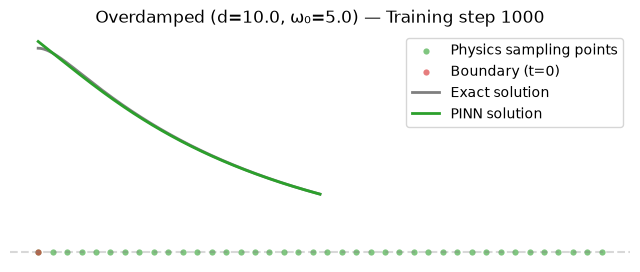

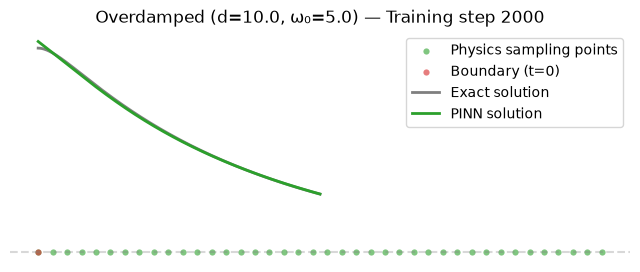

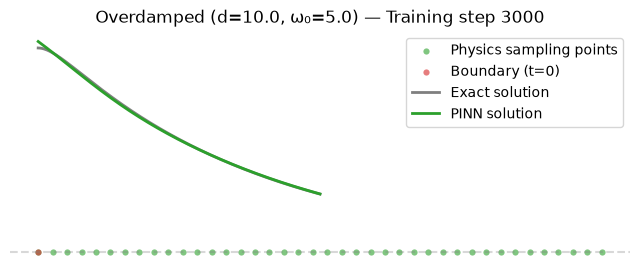

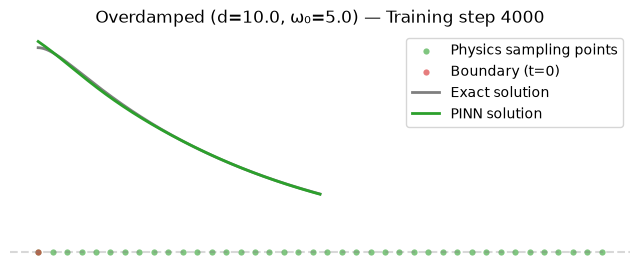

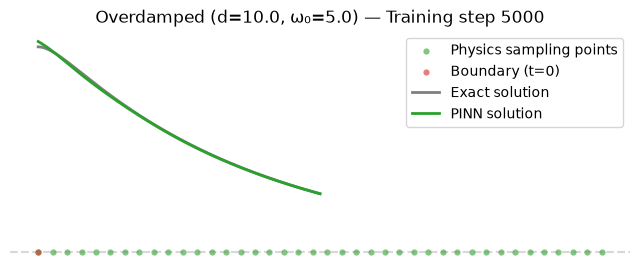

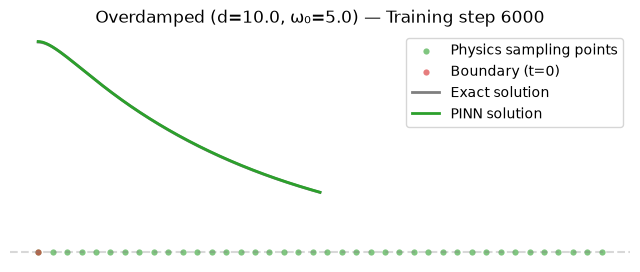

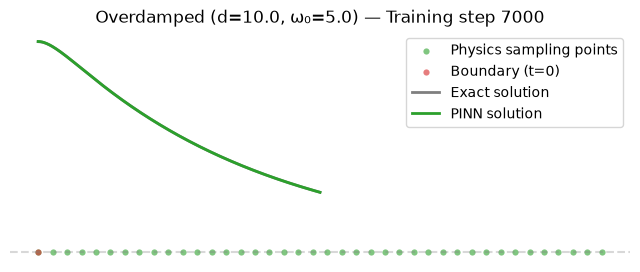

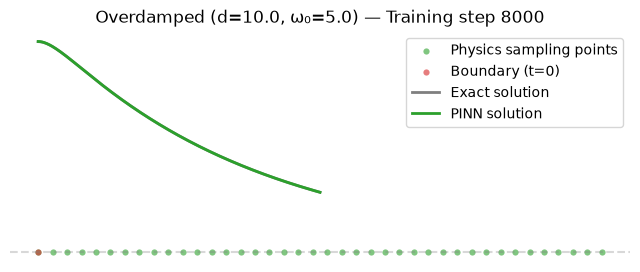

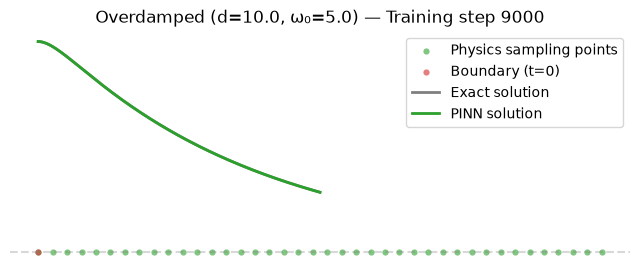

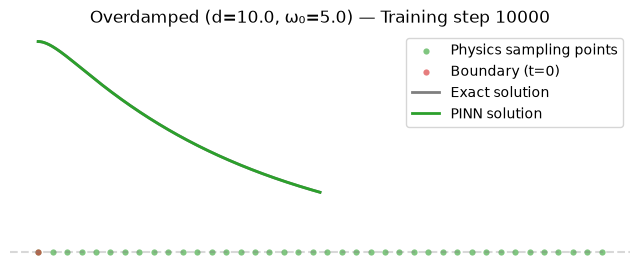

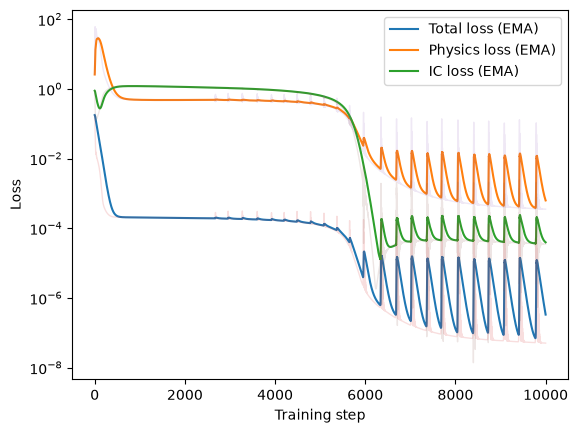

In [20]:
# Case 3: Overdamped (d > w0)
torch.manual_seed(789)

d_over, w0_over = 10.0, 5.0
pinn_over = FCN(1, 1, 32, 3)
t_boundary = torch.tensor(0.0).view(-1, 1).requires_grad_(True)
t_physics = torch.linspace(0, 2, 40).view(-1, 1).requires_grad_(True)

print("=" * 60)
print("CASE 3: OVERDAMPED OSCILLATOR")
print(f"Parameters: d = {d_over}, ω₀ = {w0_over}")
print("Since d > ω₀, the system decays slowly without oscillation")
print("=" * 60)

train_pinn(t_boundary, t_physics, pinn_over, d_over, w0_over, lambda1=1e-1, lambda2=1e-4, num_steps=10001, plot_interval=1000, t_max=2.0)

### Important Limitation: PINNs Learn ONE Solution, Not a General Solver

A natural question arises: *"After training a PINN with specific parameters (d, w0) can we use it to predict solutions for different parameter values?"*

**The answer is NO.** Each PINN learns a specific solution $x(t)$ for the parameters it was trained on. It is NOT a general differential equation solver that takes $(d, w0, t)$ as input and outputs $x$

Let's demonstrate this by evaluating our trained underdamped PINN against exact solutions for **different** parameter values:

PINN was trained with: d = 2, w0 = 20


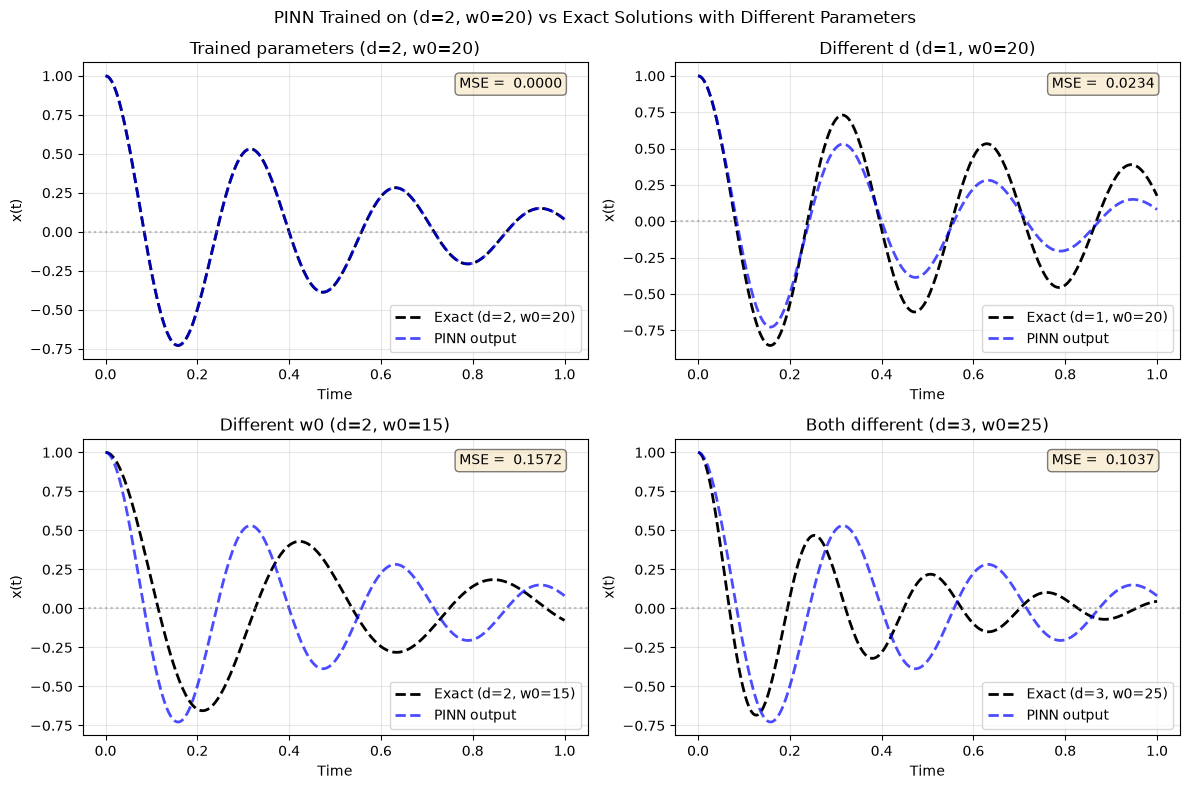


⚠️  KEY INSIGHT:
The PINN only matches the exact solution for the parameters it was trained on!
For other parameter values, the PINN output is WRONG because it learned
a specific function x(t), not a parameterized family of solutions.


In [21]:
print(f"PINN was trained with: d = {d_under}, w0 = {w0_under}")
print("=" * 60)

t_test = torch.linspace(0, 1, 300).view(-1, 1)
u_trained_pinn = pinn_under(t_test).detach()

test_params = [
    (d_under, w0_under, "Trained parameters (d=2, w0=20)"),
    (1, 20, "Different d (d=1, w0=20)"),
    (2, 15, "Different w0 (d=2, w0=15)"),
    (3, 25, "Both different (d=3, w0=25)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (d_test, w0_test, title) in zip(axes, test_params):
    u_exact = exact_solution(d_test, w0_test, t_test)

    ax.plot(t_test[:, 0], u_exact[:, 0], "k--", lw=2, label=f"Exact (d={d_test}, w0={w0_test})")
    ax.plot(t_test[:, 0], u_trained_pinn[:, 0], "b--", lw=2, alpha=0.7, label="PINN output")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("x(t)")
    ax.legend()
    ax.grid(alpha=0.3)

    mse = torch.mean((u_exact - u_trained_pinn) ** 2).item()
    ax.text(
        0.95,
        0.95,
        f"MSE = {mse: .4f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.suptitle("PINN Trained on (d=2, w0=20) vs Exact Solutions with Different Parameters")
plt.tight_layout()
plt.show()

print("\n⚠️  KEY INSIGHT:")
print("The PINN only matches the exact solution for the parameters it was trained on!")
print("For other parameter values, the PINN output is WRONG because it learned")
print("a specific function x(t), not a parameterized family of solutions.")

### Why Does This Happen?

Our PINN architecture takes only **time** as input: $\text{PINN}: t \rightarrow x$

This means:
- The network learns a fixed function $x(t)$ for specific $(d, \omega_0)$ values
- The physics parameters are **baked into the loss function** during training
- After training, the network has no way to "know" about different parameters

### How Could We Build a General Solver?

To create a PINN that works for any parameters, we'd need to include them as inputs:

$$\text{Parameterized PINN}: (t, d, \omega_0) \rightarrow x$$

This is called a **parameterized PINN** or **physics-informed operator network**. It requires:
1. Training on a diverse set of parameter combinations
2. More complex network architecture
3. Significantly more training data/time

For now, remember: **each PINN solves ONE specific problem!**

### Building a Parameterized PINN (General Solver)

We can train a PINN that takes parameters as input by **sampling many (d, w0) combinations during training**.

The key changes:
1. **Network input**: $(t, d, \omega_0) \rightarrow x$ instead of $t \rightarrow x$
2. **Training strategy**: Sample different parameters each batch
3. **Physics loss**: Use the sampled parameters in the differential equation

In [ ]:
class ParameterizedPINN(nn.Module):
    def __init__(self, N_HIDDEN=64, N_LAYERS=5):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(nn.Linear(3, N_HIDDEN), activation())
        self.fch = nn.Sequential(*[nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation()) for _ in range(N_LAYERS - 1)])
        self.fce = nn.Linear(N_HIDDEN, 1)

    def forward(self, t, d, w0):
        if not isinstance(d, torch.Tensor):
            d = torch.full_like(t, d)
        if not isinstance(w0, torch.Tensor):
            w0 = torch.full_like(t, w0)

        x = torch.cat([t, d, w0], dim=1)
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [23]:
def compute_validation_mse(pinn, t, d_val, w0_val):
    with torch.no_grad():
        d_t = torch.full_like(t, d_val)
        w0_t = torch.full_like(t, w0_val)
        x_pred = pinn(t, d_t, w0_t)
        x_exact = exact_solution(d_val, w0_val, t)
        return torch.mean((x_pred - x_exact) ** 2).item()

In [24]:
def sample_params_by_regime(N, d_min, d_max, w0_min, w0_max, frac_under, frac_crit, frac_over, crit_band):
    """Sample (d, w0) pairs with set fractions of underdamped, near-critical and overdamped cases.

    Independent uniform sampling rarely lands near d ≈ w0, which is where PINNs fail most often.
    """
    N_under = int(N * frac_under)
    N_crit = int(N * frac_crit)
    N_over = N - N_under - N_crit

    # Underdamped: pick w0, then d < w0
    w0_u = w0_min + (w0_max - w0_min) * torch.rand(N_under, 1)
    d_u = torch.rand(N_under, 1) * torch.clamp(w0_u - d_min, min=1e-6) + d_min

    # Overdamped: pick d, then w0 < d
    d_o = d_min + (d_max - d_min) * torch.rand(N_over, 1)
    w0_o = torch.rand(N_over, 1) * torch.clamp(d_o - w0_min, min=1e-6)

    # Near-critical: d = a, w0 = a(1 + eps) with |eps| <= crit_band
    a = d_min + (min(d_max, w0_max) - d_min) * torch.rand(N_crit, 1)
    eps = (2 * torch.rand(N_crit, 1) - 1) * crit_band
    d_c = a
    w0_c = torch.clamp(a * (1.0 + eps), min=w0_min + 1e-6, max=w0_max)

    d = torch.cat([d_u, d_c, d_o], dim=0)
    w0 = torch.cat([w0_u, w0_c, w0_o], dim=0)

    perm = torch.randperm(N)
    return d[perm], w0[perm]

In [25]:
def curriculum(step, num_steps):
    """Easy cases first: underdamped only, then add overdamped, then add a narrow near-critical band and raise the w0 cap."""
    p = step / num_steps

    if p < 0.3:
        return dict(frac_under=1.0, frac_crit=0.0, frac_over=0.0, crit_band=0.20, w0_cap=10.0)
    elif p < 0.7:
        return dict(frac_under=0.5, frac_crit=0.0, frac_over=0.5, crit_band=0.15, w0_cap=18.0)
    else:
        return dict(frac_under=0.45, frac_crit=0.10, frac_over=0.45, crit_band=0.05, w0_cap=25.0)

In [26]:
def residual_based_resample(pinn, M, N_keep, t_min, t_max, d_min, d_max, w0_min, w0_max, regime_kwargs, power=1.0, eps=1e-6):
    """Residual-based adaptive sampling: draw M candidate points, keep N_keep with probability ∝ |residual|^power."""
    t = (t_min + (t_max - t_min) * torch.rand(M, 1)).requires_grad_(True)
    d, w0 = sample_params_by_regime(M, d_min, d_max, w0_min, w0_max, **regime_kwargs)
    gamma = 2 * d
    k = w0 ** 2

    x = pinn(t, d, w0)
    dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    d2x = torch.autograd.grad(dx, t, torch.ones_like(dx), create_graph=True)[0]
    r = d2x + gamma * dx + k * x

    w = (r.detach().abs() ** power) + eps
    probs = (w / w.sum()).squeeze()

    idx = torch.multinomial(probs, N_keep, replacement=False)
    return t[idx].detach().requires_grad_(True), d[idx].detach(), w0[idx].detach()

In [ ]:
def train_parameterized_pinn(pinn, num_steps=20001, plot_interval=2000, lr=1e-3, n_physics_points=256, n_boundary_points=64, oversample_factor=4, ras_interval=50, d_range=(0.0, 25.0), w0_range=(1e-3, 25.0), t_range=(0.0, 1.0)):
    """Train a PINN that takes (t, d, w0) as input.

    Collocation points come from regime-stratified sampling under a curriculum, refreshed by
    residual-based resampling every `ras_interval` steps. The initial-condition weight is annealed
    and the physics weight adapts to the ratio of the two losses.
    """
    optimizer = torch.optim.Adam(pinn.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10000, gamma=0.5)

    d_min, d_max = d_range
    w0_min, w0_max = w0_range
    t_min, t_max = t_range

    val_params = [(1.5, 12.0), (3.0, 18.0), (4.0, 10.0)]
    t_val = torch.linspace(0, 1, 100).view(-1, 1)

    train_losses = []
    val_losses = []

    ratio_ema = 1.0
    ema_beta = 0.99

    t_physics = None
    d_physics = None
    w0_physics = None

    for step in range(num_steps):
        optimizer.zero_grad()

        cur = curriculum(step, num_steps)
        w0_max_eff = min(w0_max, cur["w0_cap"])
        regime_kwargs = dict(
            frac_under=cur["frac_under"],
            frac_crit=cur["frac_crit"],
            frac_over=cur["frac_over"],
            crit_band=cur["crit_band"],
        )

        if (t_physics is None) or (step % ras_interval == 0):
            t_physics, d_physics, w0_physics = residual_based_resample(
                pinn,
                M=oversample_factor * n_physics_points,
                N_keep=n_physics_points,
                t_min=t_min, t_max=t_max,
                d_min=d_min, d_max=d_max,
                w0_min=w0_min, w0_max=w0_max_eff,
                regime_kwargs=regime_kwargs,
                power=1.0,
            )
        else:
            t_physics = t_physics.detach().requires_grad_(True)

        gamma_physics = 2 * d_physics
        k_physics = w0_physics**2

        x_physics = pinn(t_physics, d_physics, w0_physics)
        dxdt = torch.autograd.grad(x_physics, t_physics, grad_outputs=torch.ones_like(x_physics), create_graph=True)[0]
        d2xdt2 = torch.autograd.grad(dxdt, t_physics, grad_outputs=torch.ones_like(dxdt), create_graph=True)[0]

        physics_residual = d2xdt2 + gamma_physics * dxdt + k_physics * x_physics
        loss_physics = torch.mean(physics_residual**2)

        t_boundary = torch.zeros(n_boundary_points, 1).requires_grad_(True)
        d_boundary, w0_boundary = sample_params_by_regime(
            n_boundary_points, d_min, d_max, w0_min, w0_max_eff, **regime_kwargs
        )

        x_boundary = pinn(t_boundary, d_boundary, w0_boundary)
        loss_ic_pos = torch.mean((x_boundary - 1) ** 2)

        dxdt_boundary = torch.autograd.grad(x_boundary, t_boundary, grad_outputs=torch.ones_like(x_boundary), create_graph=True)[0]
        loss_ic_vel = torch.mean(dxdt_boundary**2)

        loss_ic = (loss_ic_pos + loss_ic_vel)

        lambda_ic = 10000.0 * (0.1 ** (step / num_steps)) + 10.0

        with torch.no_grad():
            ratio = (loss_ic.detach() + 1e-12) / (loss_physics.detach() + 1e-12)
            ratio_ema = ema_beta * ratio_ema + (1 - ema_beta) + float(ratio)
            lambda_physics = max(1e-3, min(1e3, ratio_ema))

        loss = lambda_ic * (loss_ic_pos + loss_ic_vel) + lambda_physics * loss_physics
        loss.backward()
        optimizer.step()
        scheduler.step()

        if step % plot_interval == 0:
            pinn.eval()
            val_mse = 0.0
            for d_v, w0_v in val_params:
                val_mse += compute_validation_mse(pinn, t_val, d_v, w0_v)
            val_mse /= len(val_params)
            pinn.train()

            train_losses.append(float(loss.item()))
            val_losses.append(float(val_mse))
            print(f"Step {step}: loss={loss.item():.3e}  val_MSE={val_mse:.3e}  "
                  f"lambda_ic={lambda_ic:.2f}  lambda_phys={lambda_physics:.2f}  crit_band={cur['crit_band']:.3f}")

    plt.figure(figsize=(10, 4))
    steps = list(range(0, num_steps, plot_interval))
    plt.semilogy(steps, train_losses, "b-", label="Training loss", linewidth=2)
    plt.semilogy(steps, val_losses, "r--", label="Validation MSE vs exact", linewidth=2)
    plt.xlabel("Training step")
    plt.ylabel("Loss (log scale)")
    plt.title("Parameterized PINN training")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pinn

Step 0: loss=1.026e+04  val_MSE=2.471e-01  lambda_ic=10010.00  lambda_phys=1.13  crit_band=0.200
Step 2000: loss=6.005e+01  val_MSE=5.593e-02  lambda_ic=9271.20  lambda_phys=1.00  crit_band=0.200
Step 4000: loss=1.074e+02  val_MSE=4.959e-02  lambda_ic=8586.98  lambda_phys=1.01  crit_band=0.200
Step 6000: loss=5.609e+01  val_MSE=6.530e-02  lambda_ic=7953.31  lambda_phys=1.01  crit_band=0.200
Step 8000: loss=2.691e+01  val_MSE=5.177e-02  lambda_ic=7366.46  lambda_phys=1.01  crit_band=0.200
Step 10000: loss=1.182e+01  val_MSE=3.842e-02  lambda_ic=6822.96  lambda_phys=1.00  crit_band=0.200
Step 12000: loss=2.211e+00  val_MSE=4.285e-02  lambda_ic=6319.62  lambda_phys=1.01  crit_band=0.200
Step 14000: loss=1.550e+00  val_MSE=2.080e-02  lambda_ic=5853.47  lambda_phys=1.02  crit_band=0.200
Step 16000: loss=7.495e-01  val_MSE=1.925e-02  lambda_ic=5421.75  lambda_phys=1.03  crit_band=0.200
Step 18000: loss=1.006e+01  val_MSE=1.942e-02  lambda_ic=5021.93  lambda_phys=1.01  crit_band=0.200
Step 20

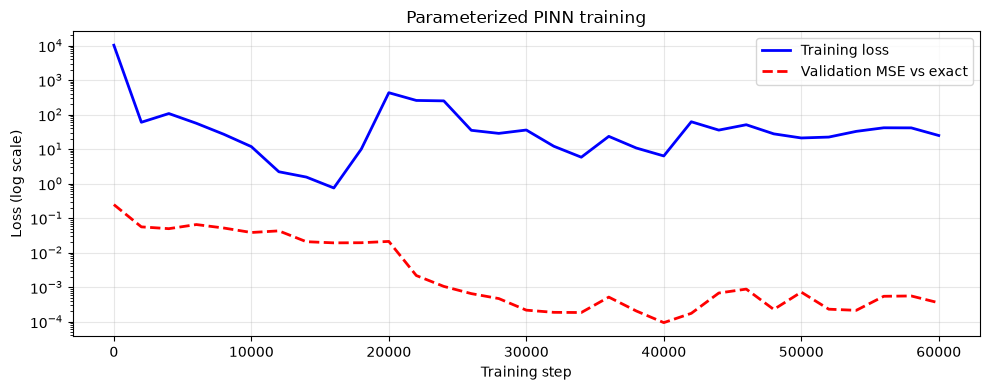

In [28]:
(d_range, w0_range) = ([0.0, 25.0], [0, 25.0])
t_max = 1.0

torch.manual_seed(42)
param_pinn = ParameterizedPINN(N_HIDDEN=128, N_LAYERS=4)
param_pinn = train_parameterized_pinn(
    param_pinn,
    num_steps=60001,
    plot_interval=2000,
    n_physics_points=256,
    n_boundary_points=32,
    d_range=d_range,
    w0_range=w0_range,
    t_range=(0.0, t_max),
)

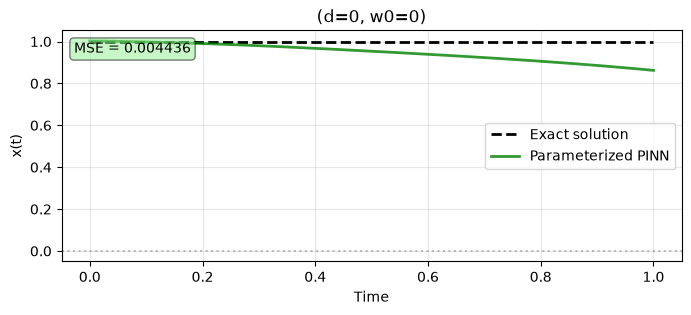

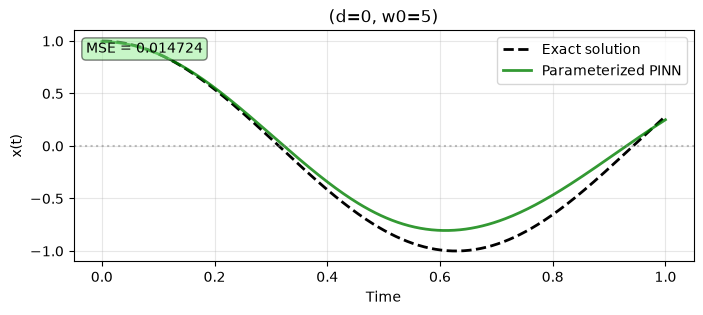

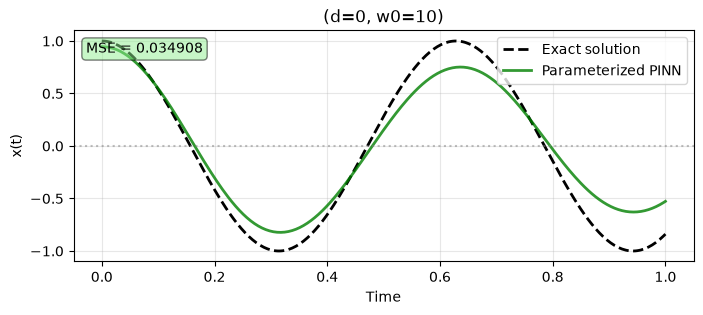

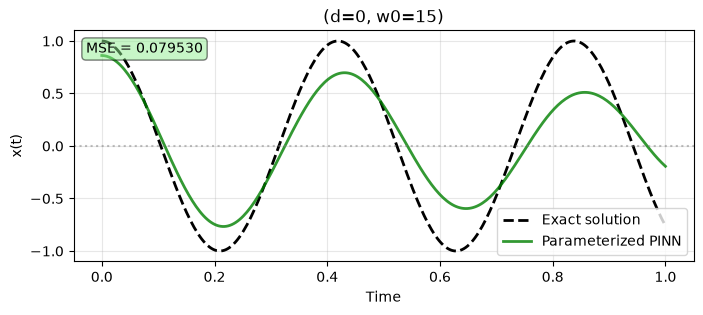

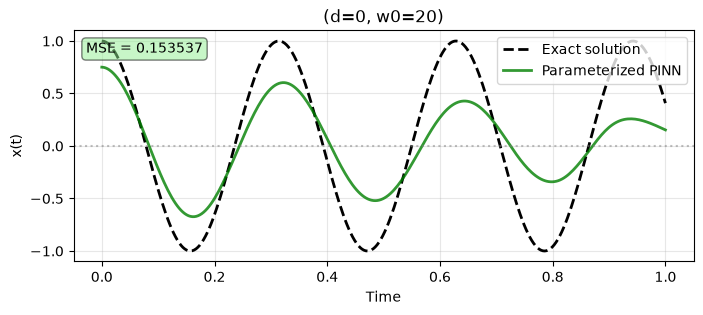

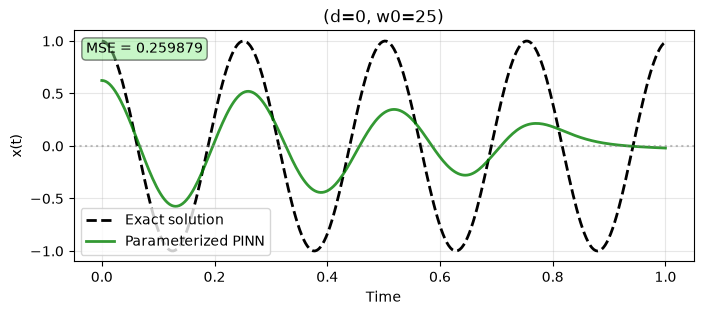

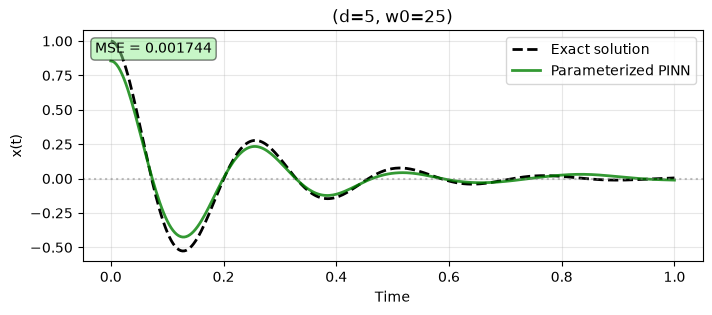

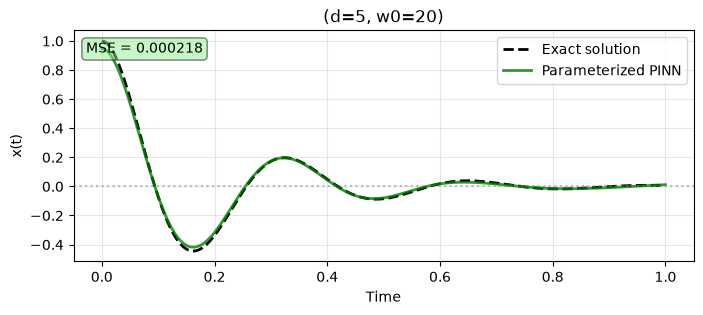

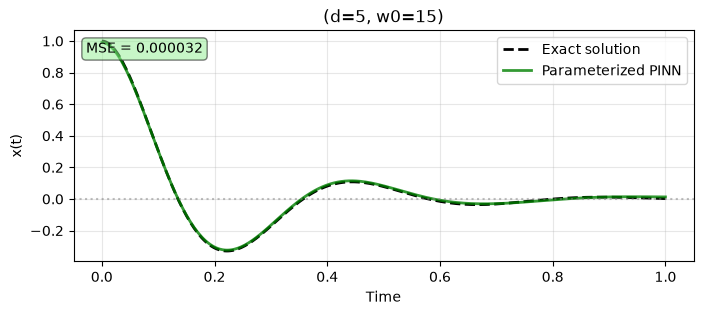

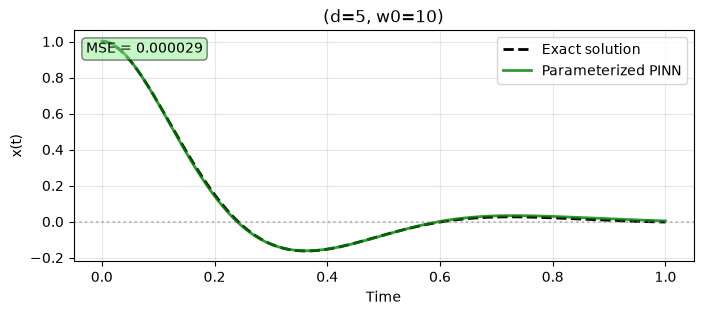

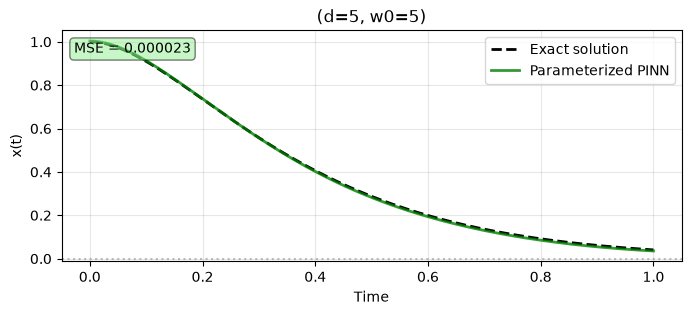

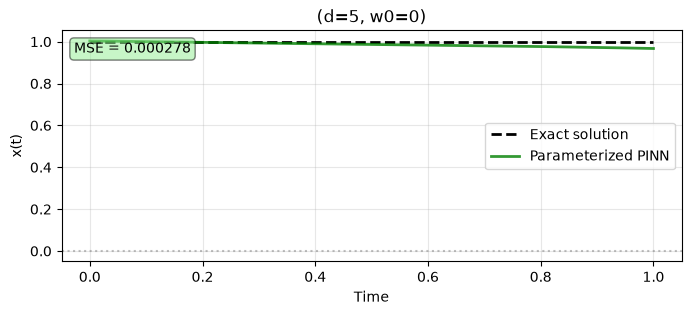

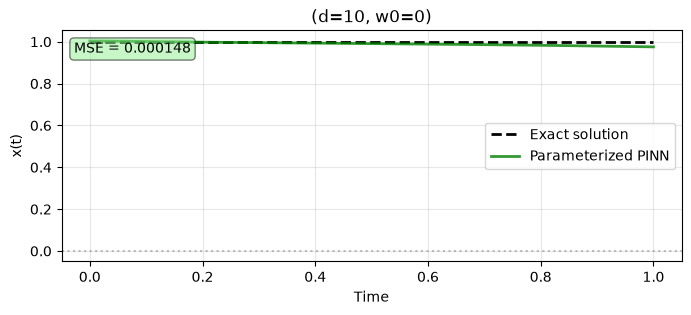

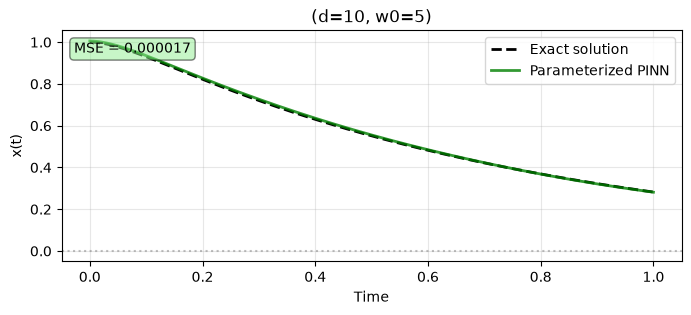

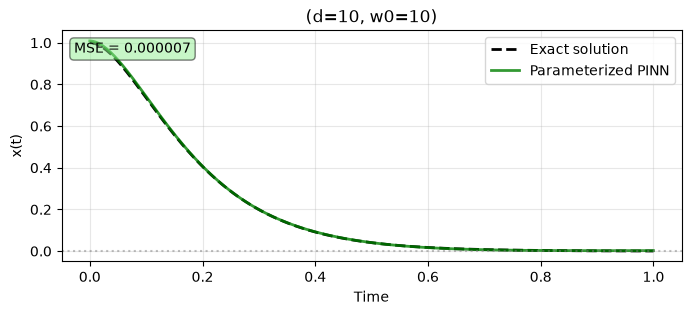

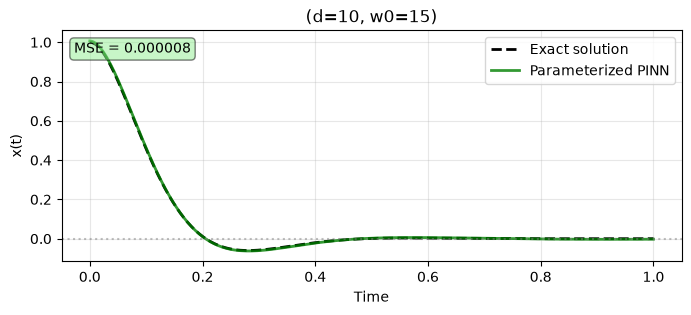

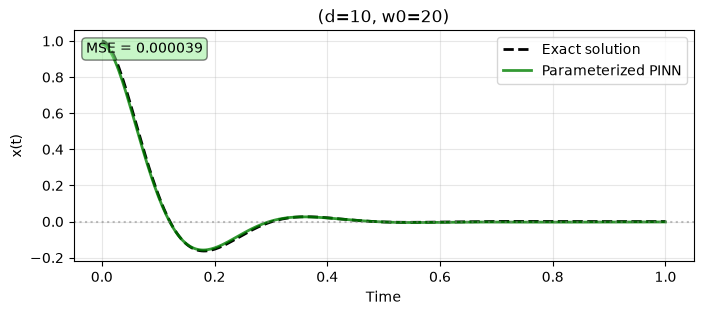

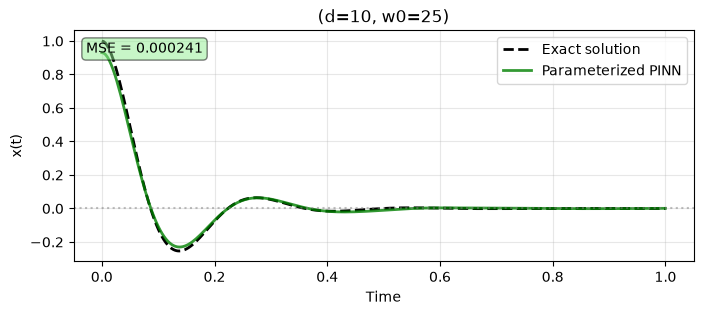

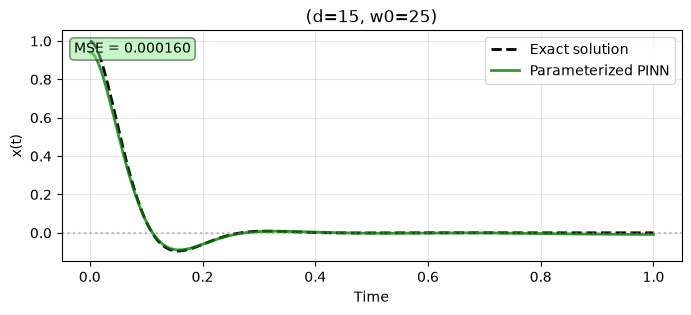

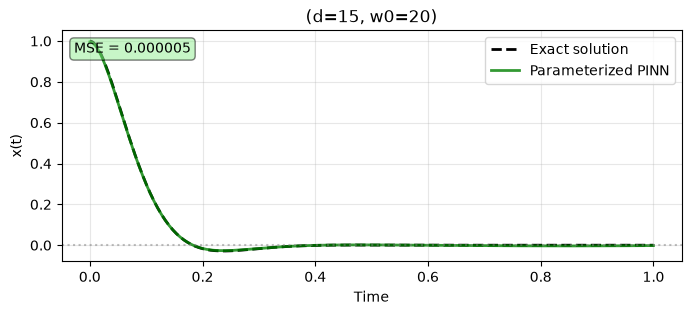

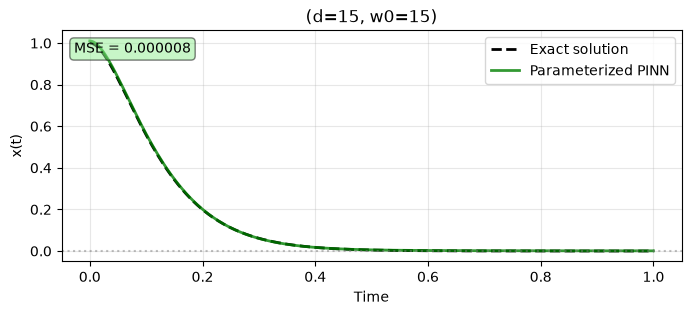

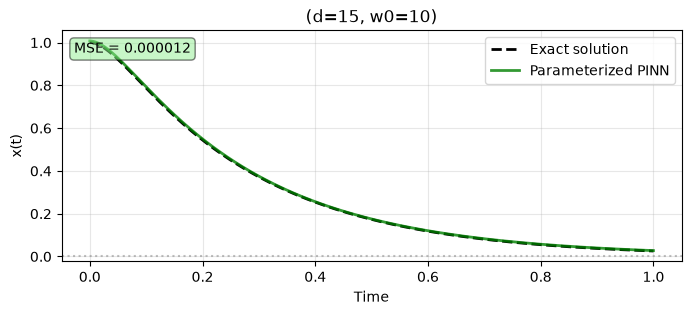

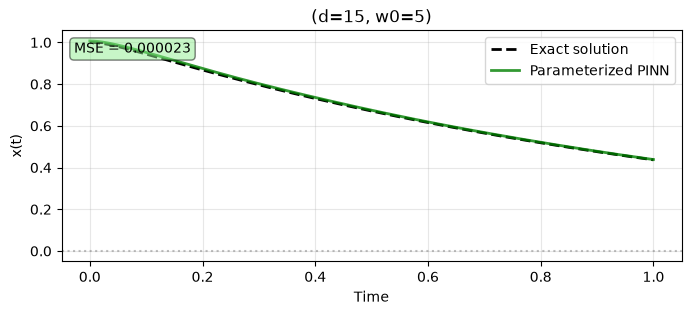

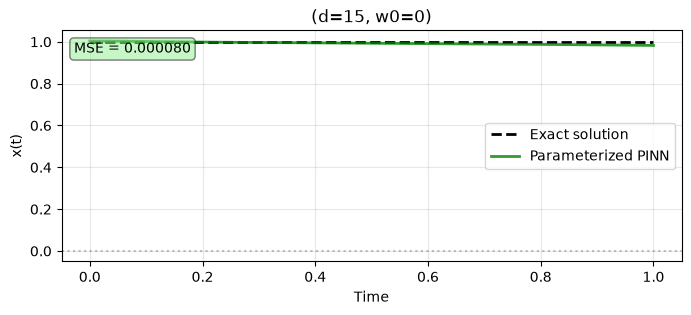

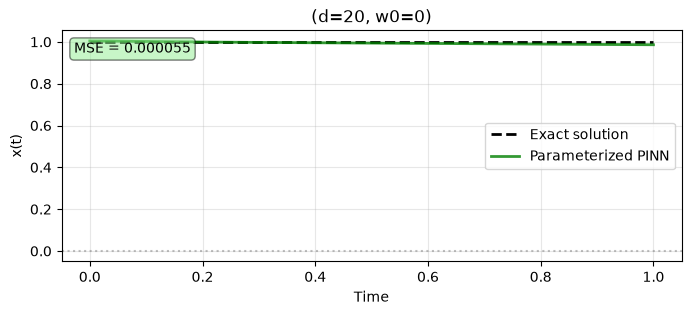

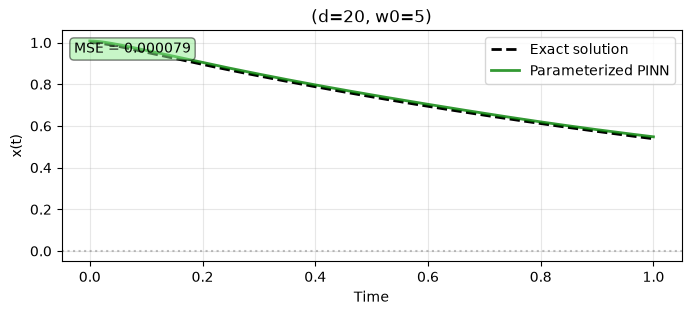

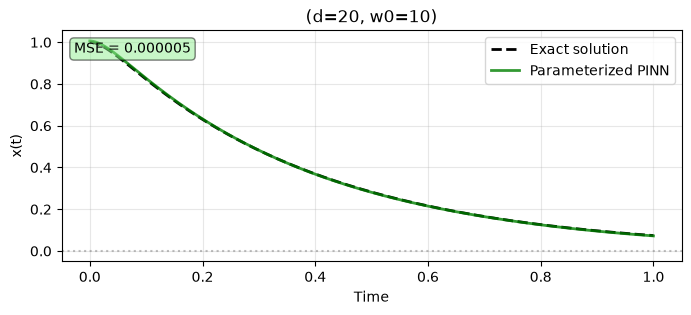

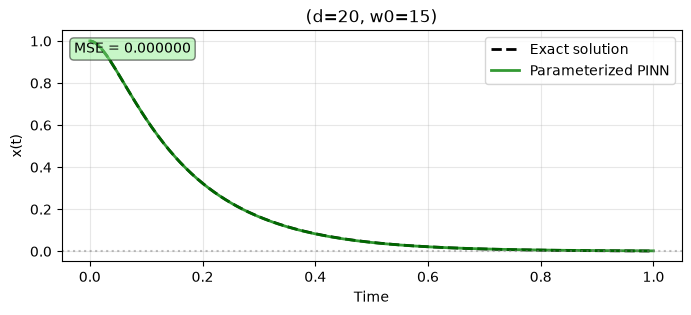

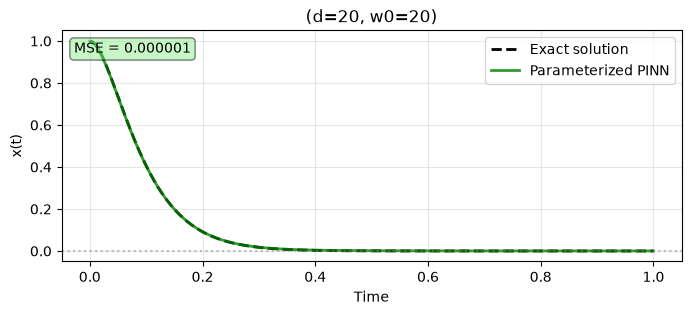

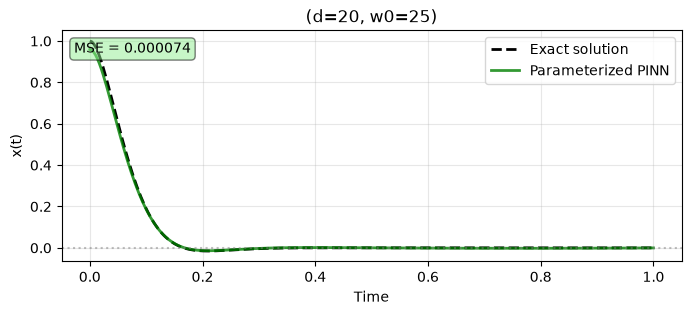

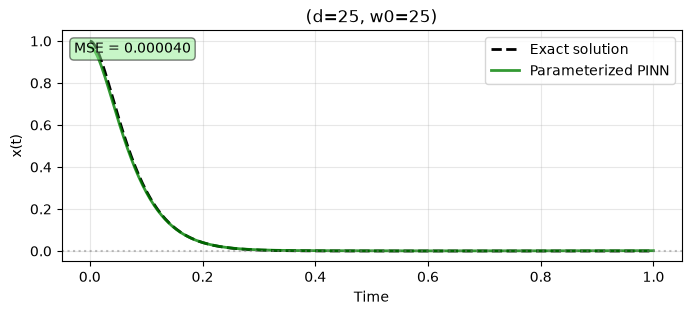

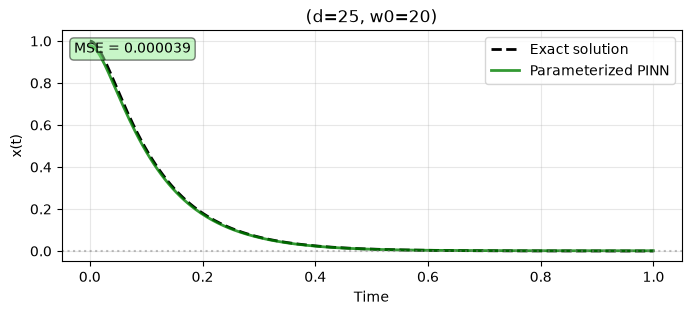

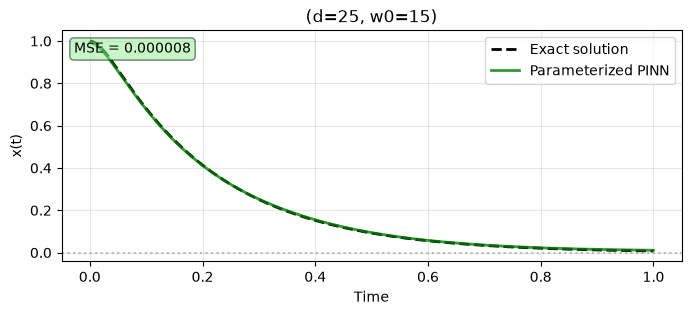

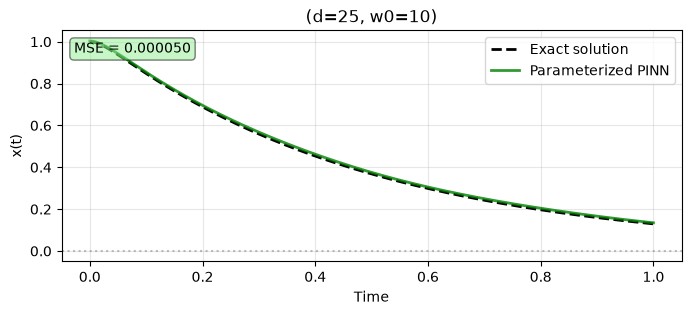

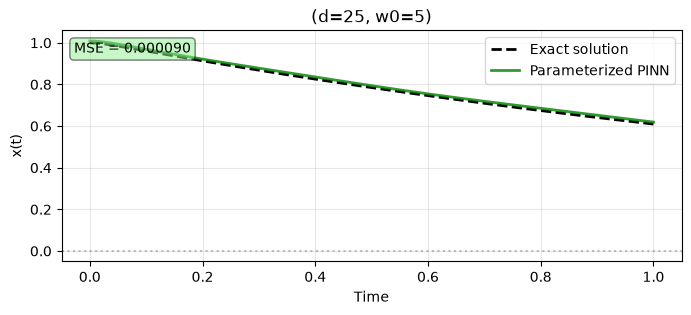

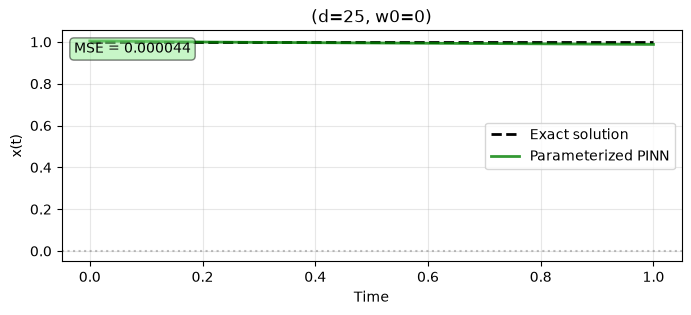

In [29]:
plot_every = 5
screencaps = 25
d_vals = np.linspace(0.0, 25.0, screencaps + 1)
w0_vals = np.linspace(0.0, 25.0, screencaps + 1)

def plot_param_pinn(t_max, param_pinn, d_vals, w0_vals):
    """Sweep a (d, w0) grid in a serpentine order and save one frame per pair for the GIF."""
    t_test = torch.linspace(0, t_max, 300).view(-1, 1)
    interval = 2 * screencaps / 25
    files = []

    for d in d_vals:
        w0_iter = w0_vals if (d % (interval) == 0) else w0_vals[::-1]

        for w0 in w0_iter:
            u_exact = exact_solution(float(d), float(w0), t_test)
            d_in = torch.full_like(t_test, float(d))
            w0_in = torch.full_like(t_test, float(w0))

            with torch.no_grad():
                u_pinn = param_pinn(t_test, d_in, w0_in)

            mse = torch.mean((u_exact - u_pinn) ** 2).item()

            fig, ax = plt.subplots(figsize=(8, 3))
            ax.plot(t_test[:, 0], u_exact[:, 0], "k--", lw=2, label="Exact solution")
            ax.plot(t_test[:, 0], u_pinn[:, 0], "g-", lw=2, alpha=0.8, label="Parameterized PINN")
            ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
            ax.set_title(f"(d={d:.3g}, w0={w0:.3g})")
            ax.set_xlabel("Time")
            ax.set_ylabel("x(t)")
            ax.legend()
            ax.grid(alpha=0.3)
            ax.text(
                0.02, 0.95, f"MSE = {mse:.6f}",
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10, bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.5),
            )

            file = PLOTS / f"d_{d:.3g}_w0_{w0:.3g}_physics.png"
            plt.savefig(file, bbox_inches="tight", pad_inches=0.1, dpi=100, facecolor="white")
            files.append(file)

            if (w0 % plot_every == 0) and (d % plot_every == 0):
                plt.show()
            plt.close(fig)

    save_gif_PIL(FIGURES / "parameterized_physics_nn.gif", files, fps=20, loop=0)

plot_param_pinn(1.0, param_pinn, d_vals, w0_vals)